In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import rasterio
import joblib
from rasterio import plot
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import math
from skimage.measure import block_reduce
from sklearn.metrics import f1_score, precision_score, recall_score
from scipy.interpolate import griddata

In [5]:
from utils.site import Site
from utils.tree import Tree
from utils.ethz_map import ETHZMap
from utils.constants import SILVER_FOLDERPATH, ETHZ_COCOA_GH_MAP_UINT8_FILEPATH

SyntaxError: invalid syntax (ethz_map.py, line 109)

In [6]:
ethz_map = ETHZMap.from_tif(ETHZ_COCOA_GH_MAP_UINT8_FILEPATH)

NameError: name 'ETHZMap' is not defined

In [ ]:
ethz_map.plot(scale_factor=50)

In [ ]:
ethz_map.plot_around_lat_lons([(6.005,-0.004)], padding_px=10, scale_factor=1)

In [11]:
# Look at each site's ETHZ map
sites = joblib.load(SILVER_FOLDERPATH / "sites.pkl")

In [12]:
s = sites[0]

In [14]:
ETHZMap.

ValueError: Number of columns must be a positive integer, not 0

<Figure size 500x600 with 0 Axes>

In [7]:
# Plot value histogram
probs = data[::100, ::100].flatten()
probs = probs[probs != 255]
probs = probs.astype('float16') / 100

Text(0.5, 1.0, 'Probability histogram [prob >=0]')

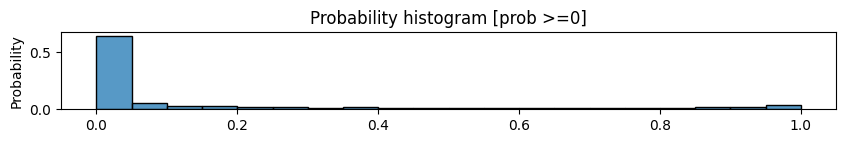

In [8]:
plt.figure(figsize=(10,1))
sns.histplot(probs[probs >= 0], stat='probability', binwidth=0.05)
plt.title("Probability histogram [prob >=0]")

In [9]:
# ETHZ paper reports ~0.9 F1 for thresh >0.65
mask = probs >= 0.9
mask.sum() 

np.int64(35637)